In [29]:
# 1. Dataset

# Use:
# Heart Disease UCI Dataset (Kaggle)
# Common columns include:

# age
# sex
# chest pain type (cp)
# blood pressure (trestbps)
# cholesterol (chol)
# fasting blood sugar (fbs)
# max heart rate (thalach)
# target (0 = no disease, 1 = disease)


# 2. Data Cleaning


import pandas as pd

df = pd.read_csv(r"C:\Users\PARAS TECH\heartdisease\heart.csv")

# check missing values
print(df.isnull().sum())

# if missing values exist
df = df.dropna()   # or use fillna()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


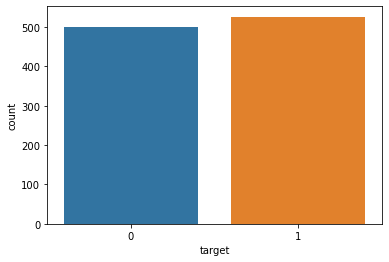

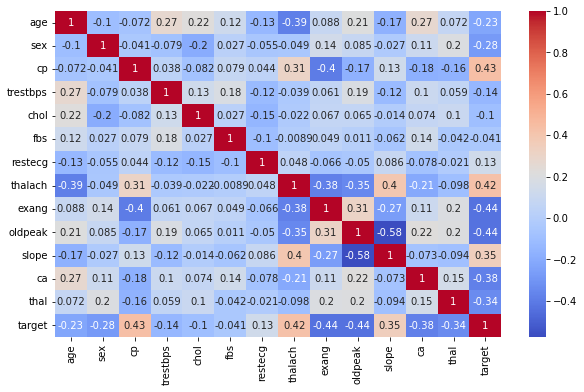

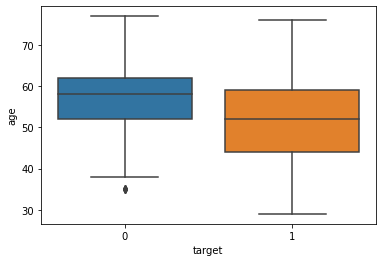

In [39]:
# 3. Exploratory Data Analysis (EDA)


import seaborn as sns
import matplotlib.pyplot as plt

# Target distribution
sns.countplot(x='target', data=df)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Age vs Heart Disease
sns.boxplot(x='target', y='age', data=df)
plt.show()

In [31]:
# 4. Model Training (Logistic Regression / Decision Tree)
# Option 1: Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [33]:
# Option 2: Decision Tree

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [34]:
# 5. Model Evaluation
# Accuracy

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


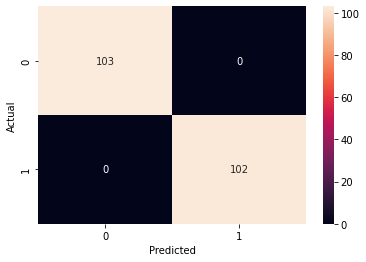

In [36]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

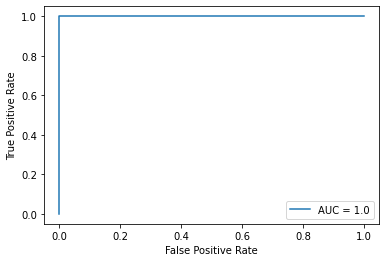

In [37]:
# ROC Curve

from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = "+str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [38]:
# Decision Tree:

import pandas as pd

importance = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_df)

     Feature  Importance
2         cp    0.262194
11        ca    0.146907
0        age    0.096327
12      thal    0.088742
9    oldpeak    0.088622
7    thalach    0.077742
4       chol    0.063244
1        sex    0.046570
3   trestbps    0.035179
10     slope    0.035101
8      exang    0.023981
6    restecg    0.019043
5        fbs    0.016349
